# BirdsEye sandbox — VWAP skew / strangle (no fallback)

Same as `vwap_skew_strangle` but with **regime 4 (the wide fallback) removed**.
When none of the three regimes apply, the strategy stays **flat** — capital sits
idle rather than shorting a wide ±4 strangle.

Regimes (picked each second; first match wins):

1. **spot ≥ VWAP + 20 bps** → skew: short PUT far (−3) + CALL near (+1), pyramided 1–2–3–4, trailing stop / profit limit, 20-min max hold.
2. **spot ≤ VWAP − 20 bps** → mirror: short CALL far (+3) + PUT near (−1).
3. **else, trailing-15-min range < 15 bps** → tight strangle bracketing spot, 10/side, 30-min hold.
4. **else** → **flat** (no position).

Everything else is unchanged from the fallback version: volume-weighted VWAP
(`fields` includes `volume`), `cost_kwargs={"txn_cost_per_lot": 0.85}`, and the
`quote_persist` liquidity guard that keeps the executor from starving.

In [ ]:
from engine import BirdsEye
from strategies.vwap_skew_strangle_nofallback import VwapSkewStrangleNoFallback

# All paths (manifest, intern-project dir) come from BirdsEye/.env — nothing hardcoded here.
be_vss = BirdsEye(
    strategy_cls    = VwapSkewStrangleNoFallback,
    index           = "SPY",
    split           = "train",                          # "val" / "test" to evaluate
    # load volume on top of the default quote fields so VWAP is volume-weighted:
    fields          = ("spot", "atm_strike",
                       "ce_bid_0", "ce_ask_0", "pe_bid_0", "pe_ask_0",
                       "volume"),
    strategy_kwargs = {
        "lots":             10,        # 10/side -> 20 lots total ("10 pairs")
        "dev_bps_thresh":   20.0,      # |spot-VWAP| trigger for regimes 1/2
        "range_bps_max":    15.0,      # trailing-range ceiling for regime 3
        "range_win":        900,       # 15-min trailing window (also the warm-up)
        "pyramid_schedule": (1, 2, 3, 4),
        "group_interval":   10*60,        # secs between pyramid groups
        "skew_max_hold":    2*60*60,      # regimes 1/2 max hold (20 min)
        "tight_hold":       2*60*60,      # regime 3 hold (30 min)
        "profit_take_frac": 1.0,      # profit limit as a fraction of credit
        "trail_frac":       0.25,      # trailing give-back as a fraction of credit
        # --- VWAP / liquidity controls ---
        "vwap_use_volume":      True,      # volume-weight VWAP (needs the 'volume' field)
        "volume_field":         "volume",  # name of your underlying volume column
        "volume_is_cumulative": False,     # True if that column is a running total
        "quote_persist":        60,        # secs a strike must stay quoted to be tradable
    },
    lot_size        = 100,
    starting_cash   = 1_000_000.0,
    cost_kwargs     = {"txn_cost_per_lot": 0.85},        # $0.85 per lot per fill
    n_workers       = 40,
    # days=["20240102", "20240104"],                    # uncomment for a quick subset
)
res = be_vss.run()

In [2]:
# FSM wiring (build a throwaway instance just to print the state graph)
from engine import Broker, Portfolio, CostModel, Tradelog
_probe = VwapSkewStrangleNoFallback(broker=Broker(Portfolio(100, 0.0), CostModel(100), Tradelog()), lots=10)
print(f"{VwapSkewStrangleNoFallback.__name__} FSM:")
print(_probe.describe())
print(f"\nslice_lots={_probe.slice_lots}  pause={_probe.pause}  "
      f"n_groups={_probe.n_groups}  schedule={_probe.pyramid_schedule}  "
      f"min_history={_probe.min_history}s  quote_persist={_probe.quote_persist}s")

VwapSkewStrangleNoFallback FSM:
      WAIT --[above_vwap]--> SKEW_ADD
      WAIT --[below_vwap]--> SKEW_ADD
      WAIT --[calm_range]--> TIGHT
  SKEW_ADD --[eod_flat]--> WAIT
  SKEW_ADD --[always_hold]--> SKEW_HOLD
 SKEW_HOLD --[eod_flat]--> WAIT
 SKEW_HOLD --[skew_exit]--> WAIT
 SKEW_HOLD --[skew_add]--> SKEW_ADD
 SKEW_HOLD --[skew_freeze]--> SKEW_FROZEN
SKEW_FROZEN --[eod_flat]--> WAIT
SKEW_FROZEN --[skew_exit]--> WAIT
     TIGHT --[eod_flat]--> WAIT
     TIGHT --[tight_done]--> WAIT

slice_lots=10  pause=0  n_groups=4  schedule=(1, 2, 3, 4)  min_history=900s  quote_persist=60s


=== per-day summary ===


,fills,gross($),costs($),net($)
day,,,,
20240102,14,99.0,80.6,18.4
20240104,8,-250.0,138.0,-388.0
20240105,8,890.0,108.0,782.0
20240109,32,-358.0,118.0,-476.0
20240110,8,455.0,113.0,342.0
...,...,...,...,...
20250804,26,348.0,125.2,222.8
20250806,32,43.5,109.5,-66.0
20250807,44,-351.5,131.7,-483.2


=== aggregate stats ===
  n_days          : 277
  total_pnl       : -13064.2
  avg_day         : -47.16
  pct_pos_days    : 0.54
  pct_neg_days    : 0.46
  avg_win         : 460.13
  avg_loss        : -637.68
  best_day        : 1418.0
  worst_day       : -4638.0
  win_rate        : 0.54
  cagr            : -0.01
  calmar          : -0.61
  maxDD_pct       : -0.02
  churn_per_day   : 0.01
  daily_maxDD     : -19695.0
  intraday_maxDD  : -6610.0
  total_costs     : 30935.2
  n_fills         : 4216


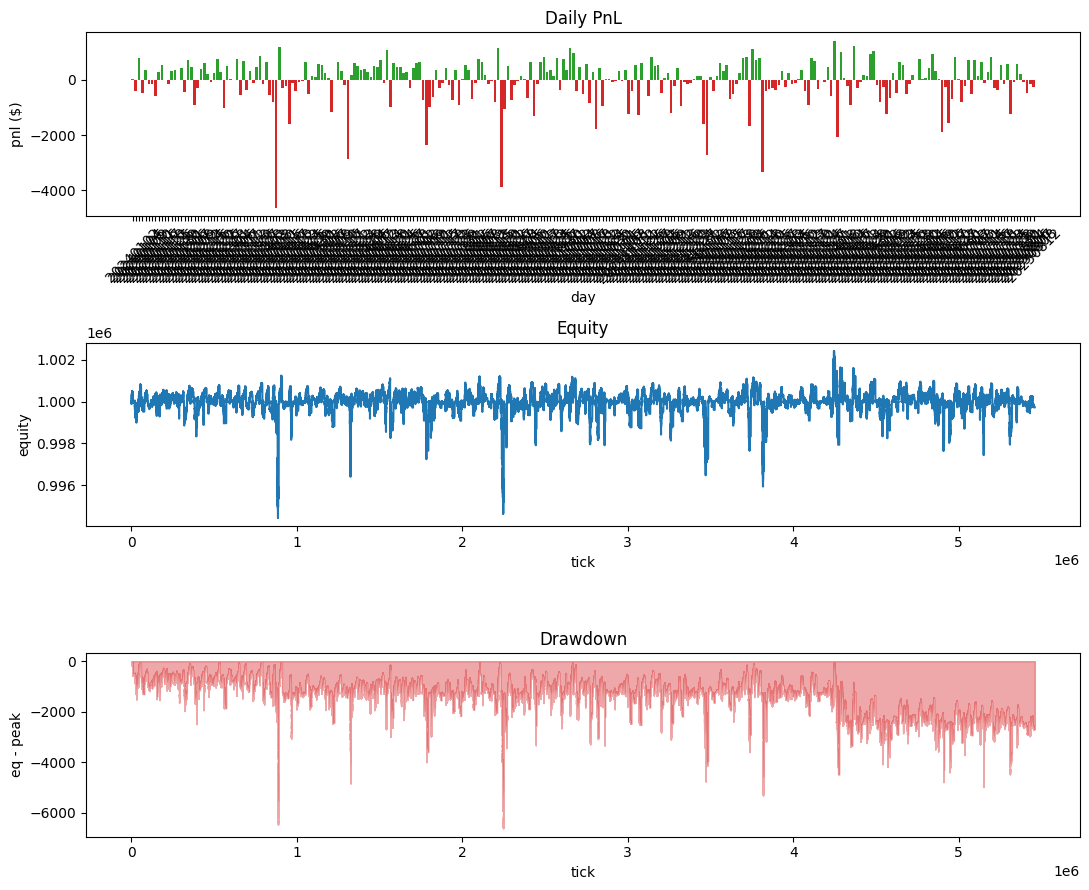

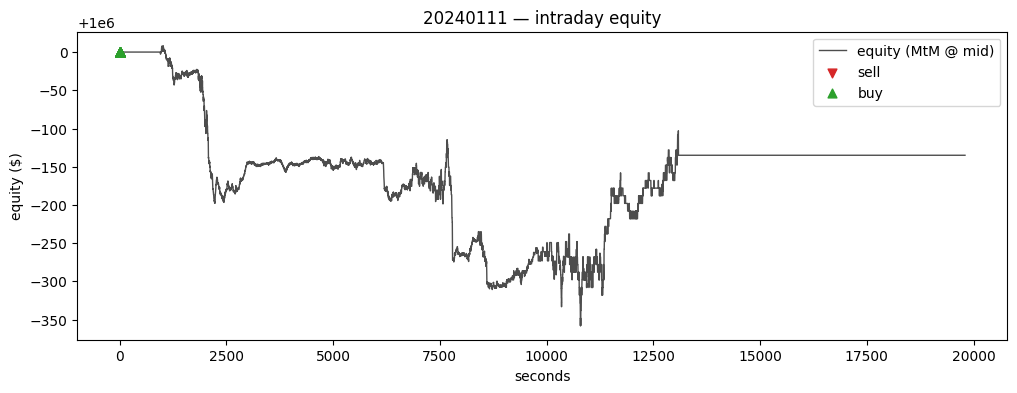

=== trade ledger: 4216 fills ===


,day,timestamp,strike,opt_type,action,lots,fill_price,txn_cost,brokerage,spread_cost,...,alpha_c1_ce,alpha_c1_pe,alpha_c2_ce,alpha_c2_pe,alpha_t_ce,alpha_t_pe,alpha_c1_ok,alpha_c2_ok,alpha_t_ok,alpha_skew_legs_ok
0,20240102,1452,472.0,CE,SELL,10.0,0.74,8.50,0.0,5.0,...,472.0,468.0,474.0,470.0,472.0,471.0,1.0,1.0,1.0,1.0
1,20240102,1452,471.0,PE,SELL,10.0,0.74,8.50,0.0,5.0,...,472.0,468.0,474.0,470.0,472.0,471.0,1.0,1.0,1.0,1.0
2,20240102,8652,472.0,CE,BUY,10.0,1.31,8.50,0.0,10.0,...,474.0,470.0,476.0,472.0,474.0,473.0,1.0,1.0,1.0,1.0
3,20240102,8652,471.0,PE,BUY,10.0,0.12,8.50,0.0,5.0,...,474.0,470.0,476.0,472.0,474.0,473.0,1.0,1.0,1.0,1.0
4,20240102,8664,474.0,CE,SELL,1.0,0.30,0.85,0.0,0.5,...,474.0,470.0,476.0,472.0,474.0,473.0,1.0,1.0,1.0,1.0
5,20240102,8664,470.0,PE,SELL,1.0,0.06,0.85,0.0,0.5,...,474.0,470.0,476.0,472.0,474.0,473.0,1.0,1.0,1.0,1.0
6,20240102,11305,474.0,CE,BUY,1.0,0.36,0.85,0.0,0.5,...,474.0,470.0,476.0,472.0,474.0,473.0,1.0,1.0,1.0,1.0
7,20240102,11305,470.0,PE,BUY,1.0,0.04,0.85,0.0,0.5,...,474.0,470.0,476.0,472.0,474.0,473.0,1.0,1.0,1.0,1.0
8,20240102,11307,474.0,CE,SELL,1.0,0.36,0.85,0.0,0.5,...,474.0,470.0,476.0,472.0,474.0,473.0,1.0,1.0,1.0,1.0
9,20240102,11307,470.0,PE,SELL,1.0,0.04,0.85,0.0,0.5,...,474.0,470.0,476.0,472.0,474.0,473.0,1.0,1.0,1.0,1.0


fills & costs by signal:


,count,sum
signal,,
above_vwap,394,609.9
below_vwap,540,830.5
calm_range,642,9102.0
eod_flat,2,27.0
skew_add,1064,4115.7
skew_exit,934,5825.1
tight_done,640,10425.0


=== per-second log 20240111: 19780 rows ===


,timestamp,spot,atm,state,sec,vwap,bars_left,dev_bps,range_bps,upnl,...,c1_ce,c1_pe,c2_ce,c2_pe,t_ce,t_pe,c1_ok,c2_ok,t_ok,skew_legs_ok
2000,2004,475.54,476.0,SKEW_HOLD,2004.0,476.92,17796.0,-28.86,18.93,-52.0,...,477.0,473.0,479.0,475.0,476.0,475.0,1.0,1.0,1.0,1.0
2001,2005,475.54,476.0,SKEW_HOLD,2005.0,476.92,17795.0,-28.86,18.93,-58.0,...,477.0,473.0,479.0,475.0,476.0,475.0,1.0,1.0,1.0,1.0
2002,2006,475.51,476.0,SKEW_HOLD,2006.0,476.92,17794.0,-29.47,19.56,-61.0,...,477.0,473.0,479.0,475.0,476.0,475.0,1.0,1.0,1.0,1.0
2003,2007,475.50,476.0,SKEW_HOLD,2007.0,476.91,17793.0,-29.67,19.77,-58.0,...,477.0,473.0,479.0,475.0,476.0,475.0,1.0,1.0,1.0,1.0
2004,2008,475.50,476.0,SKEW_HOLD,2008.0,476.91,17792.0,-29.65,19.77,-59.5,...,477.0,473.0,479.0,475.0,476.0,475.0,1.0,1.0,1.0,1.0


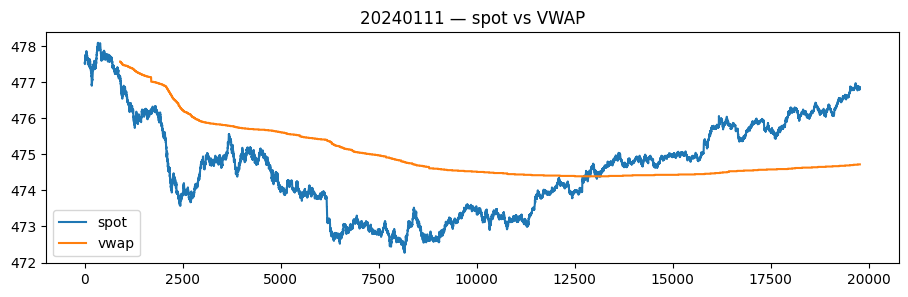

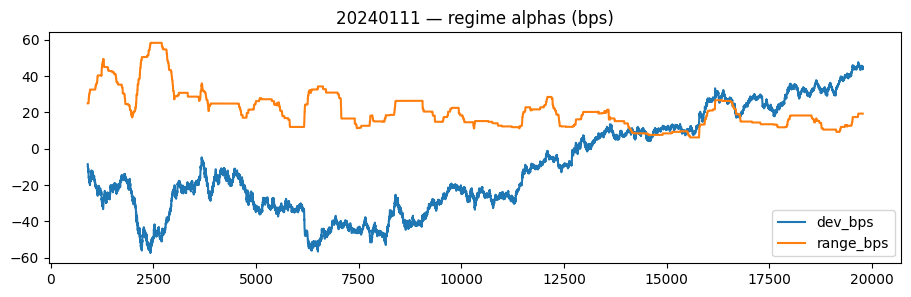

In [4]:
import matplotlib.pyplot as plt

DAY = res.days[5]          # first day in the run (any value in res.days works)

# ---- 1. per-day summary table ----
print("=== per-day summary ===")
display(res.summary)

# ---- 2. aggregate stats ----
print("=== aggregate stats ===")
for k, v in res.stats().items():
    print(f"  {k:<16}: {v}")

# ---- 3. plots: daily PnL / stitched equity / drawdown ----
res.tearsheet()
plt.show()

# ---- 4. single-day deep dive: intraday MtM with buy/sell markers ----
res.plot_day(DAY)
plt.show()

# ---- 5. trade ledger (all days), grouped by which regime/signal fired ----
led = res.Tradelog()
print(f"=== trade ledger: {len(led)} fills ===")
display(led.head(10))                                   # alpha_* cols show fire-time values
print("fills & costs by signal:")
display(led.groupby("signal")["exe_cost"].agg(["count", "sum"]).round(2))

# ---- 6. per-second log for one day: the two headline alphas + VWAP vs spot ----
sl = res.perseclog(DAY)
print(f"=== per-second log {DAY}: {len(sl)} rows ===")
display(sl.iloc[2000:2005])                             # spot, atm, vwap, state, every alpha
sl.plot(y=["spot", "vwap"], figsize=(11, 3), title=f"{DAY} — spot vs VWAP")
plt.show()
sl.plot(y=["dev_bps", "range_bps"], figsize=(11, 3), title=f"{DAY} — regime alphas (bps)")
plt.show()

In [5]:
# ============================================================================
# PnL statistics by TRADE TYPE (one episode = one round trip)
#   skew  : above_vwap / below_vwap  +  its skew_add slices  +  skew_exit
#   tight : calm_range  +  tight_done
# (no wide/fallback type in this variant)
# mid-p PnL uses ONLY fill prices (SELL = +price, BUY = -price) x lots x lot_size.
# Episodes flattened at the close carry the 'eod_flat' signal (a universal closer).
# t-cost is the ledger's exe_cost (txn + brokerage + spread). Values come from the
# ledger, whose fill_price is rounded to 2 dp, so totals can differ from account
# equity by a few dollars of rounding.
# ============================================================================
import numpy as np
import pandas as pd

_OPENERS = {"above_vwap": "skew", "below_vwap": "skew", "calm_range": "tight"}
_ADDERS  = {"skew_add": "skew"}
_CLOSERS = {"skew_exit": "skew", "tight_done": "tight"}


def _segment(df):
    """Time-ordered fills -> trade episodes. Multi-leg orders share a (timestamp,
    signal), so collapse contiguous same-signal rows into one phase first, then walk
    phases: an opener starts an episode, it absorbs the following skew_add phase(s),
    and ends on its closer phase."""
    df   = df.reset_index(drop=True)
    sigs = df["signal"].tolist()
    runs, start = [], 0
    for k in range(1, len(df) + 1):
        if k == len(df) or sigs[k] != sigs[start]:
            runs.append(df.iloc[start:k]); start = k

    eps, cur = [], None
    for run in runs:
        sig = run["signal"].iloc[0]
        if sig in _OPENERS:
            if cur is not None:
                eps.append(cur)
            cur = {"type": _OPENERS[sig], "fills": [run]}
        elif cur is not None:
            cur["fills"].append(run)
            if sig in _CLOSERS or sig == "eod_flat":
                eps.append(cur); cur = None
        else:                                            # orphan add/close (no open episode)
            t = _ADDERS.get(sig) or _CLOSERS.get(sig) or "unknown"
            cur = {"type": t, "fills": [run]}
            if sig in _CLOSERS or sig == "eod_flat":
                eps.append(cur); cur = None
    if cur is not None:
        eps.append(cur)

    for e in eps:
        e["fills"] = pd.concat(e["fills"], ignore_index=True)
    return eps


def _episode_stats(ep, lot_size):
    f       = ep["fills"]
    sign    = np.where(f["action"] == "SELL", 1.0, -1.0)     # SELL = cash in, BUY = cash out
    midp    = float((sign * f["fill_price"] * f["lots"] * lot_size).sum())
    tcost   = float(f["exe_cost"].sum())
    openl   = float(f.loc[f["action"] == "SELL", "lots"].sum())          # lots shorted to open
    net_pos = float(np.where(f["action"] == "BUY", f["lots"], -f["lots"]).sum())
    return {"type": ep["type"], "n_fills": len(f), "midp_pnl": midp, "tcost": tcost,
            "net_pnl": midp - tcost, "open_lots": openl, "flat": abs(net_pos) < 1e-9}


def trade_pnl_stats(led, lot_size, verbose=True):
    """Per-trade-type PnL stats from a BirdsEye ledger (e.g. res.Tradelog()).
    Returns (per_type_table, per_trade_table)."""
    if led is None or len(led) == 0:
        if verbose: print("empty ledger - no trades")
        return pd.DataFrame(), pd.DataFrame()

    eps = []
    if "day" in led.columns:                              # segment within each day (flat overnight)
        for _, g in led.groupby("day", sort=True):
            eps += _segment(g)
    else:
        eps = _segment(led)

    per_trade = pd.DataFrame([_episode_stats(e, lot_size) for e in eps])

    order = ["skew", "tight"]
    agg = per_trade.groupby("type").agg(
        trades=("type", "size"), midp_pnl=("midp_pnl", "sum"),
        tcost=("tcost", "sum"), net_pnl=("net_pnl", "sum"),
        open_lots=("open_lots", "sum"))
    agg = agg.reindex([t for t in order if t in agg.index]
                      + [t for t in agg.index if t not in order])
    agg["midp_per_lot"]    = agg["midp_pnl"] / agg["open_lots"].replace(0, np.nan)
    agg["midp_per_trade"]  = agg["midp_pnl"] / agg["trades"]
    agg["tcost_per_trade"] = agg["tcost"]    / agg["trades"]

    total = pd.Series({
        "trades": agg["trades"].sum(), "midp_pnl": agg["midp_pnl"].sum(),
        "tcost": agg["tcost"].sum(), "net_pnl": agg["net_pnl"].sum(),
        "open_lots": agg["open_lots"].sum(),
        "midp_per_lot":    agg["midp_pnl"].sum() / max(agg["open_lots"].sum(), 1e-9),
        "midp_per_trade":  agg["midp_pnl"].sum() / max(agg["trades"].sum(), 1),
        "tcost_per_trade": agg["tcost"].sum()    / max(agg["trades"].sum(), 1),
    }, name="TOTAL")
    table = pd.concat([agg, total.to_frame().T])

    if verbose:
        show = table.copy()
        for c in ["midp_pnl", "tcost", "net_pnl", "midp_per_lot", "midp_per_trade", "tcost_per_trade"]:
            show[c] = show[c].astype(float).round(2)
        show["trades"]    = show["trades"].astype(int)
        show["open_lots"] = show["open_lots"].astype(float).round(0).astype(int)
        print("=== PnL by trade type (mid-price) ===")
        print(show.to_string())
        n_open = int((~per_trade["flat"]).sum()) if len(per_trade) else 0
        if n_open:
            print(f"\nNote: {n_open} episode(s) did not end flat; their mid-p PnL "
                  f"includes an open position and is not a realised round trip.")
        print(f"\nTOTAL NET PnL (after costs):          {table.loc['TOTAL','net_pnl']:,.2f}")
        print(f"TOTAL mid-p PnL (before costs):       {table.loc['TOTAL','midp_pnl']:,.2f}")
        print(f"TOTAL t-costs:                        {table.loc['TOTAL','tcost']:,.2f}")
        print(f"mid-p PnL per opening lot (overall):  {table.loc['TOTAL','midp_per_lot']:,.4f}")
    return table, per_trade


# ---- run it on this backtest's ledger --------------------------------------
pnl_by_type, pnl_by_trade = trade_pnl_stats(res.Tradelog(), lot_size=res.lot_size)


=== PnL by trade type (mid-price) ===
       trades  midp_pnl    tcost  net_pnl  open_lots  midp_per_lot  midp_per_trade  tcost_per_trade
skew      467    5676.0  11381.2  -5705.2       3776          1.50           12.15            24.37
tight     321   12050.0  19554.0  -7504.0       6420          1.88           37.54            60.92
TOTAL     788   17726.0  30935.2 -13209.2      10196          1.74           22.49            39.26

TOTAL NET PnL (after costs):          -13,209.20
TOTAL mid-p PnL (before costs):       17,726.00
TOTAL t-costs:                        30,935.20
mid-p PnL per opening lot (overall):  1.7385
